## 1.0- Notebook Setup

Import the libraries used for table parsing, type cleaning, quick inspection, and plotting later in the analysis.

In [410]:
import json
import re
from pathlib import Path
from itables import show
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# Jack Coleman (21207103)
**Data Analysis Notebook**
**Dublin Rental Market Analysis**

# 1- Pre-Analysis Processing

## 1.1- Data Ingestion

The first step of the data analysis process is to ingest the raw data collected from the web scraping phase. I stored the data in a JSON file named 'transactions.json', and so I  will read this file using the 'json' library, before converting it directly into a pandas DataFrame for easier manipulation and analysis. The head of this dataframe (the first three entries) has been displayed below to provide an initial glimpse of the raw data structure and content.


In [411]:
payload = json.loads(Path("transactions.json").read_text(encoding="utf-8"))

rows = []
for batch_index, batch in enumerate(payload):
    for row_index, row in enumerate(batch):
        rows.append({**row})

cleaning_staging_table = pd.DataFrame(rows)
cleaning_staging_table.head(3)


,header,price,location,bedrooms,bathrooms,parking,garden,lease_length,contact
0,January 2025 — Apartment,840.00 per month,Dublin City South — Dublin 12,1,2 Bathrooms,Y,0,12 months,Estate Agent
1,January 2025 — House,"€ 3,110.00",Dublin City Nth. - D1,3 Bedrooms,1 Bathroom,True,Yes,6 months,Owner
2,January 2025 — Apartment,"€2,170 per month",Dublin City South - Dublin 2,2,1 Bathroom,Not Available,N/A,12 months,estate agent


## 1.2- Header Parsing

The next step will be the parsing of the header field, which contains a combination of the listing month, year, and property type. The goal is to extract these components into separate columns for easier analysis. This involves splitting the header text based on known delimiters (such as spaces and dashes) and applying string manipulation techniques to clean and standardize the extracted values.

After parsing, I can collect a set (list of unique values) to ensure that any anomolies or unexpected values are identified and can be addressed in the cleaning process. This step is crucial for ensuring that the data is structured correctly for subsequent analysis and that any inconsistencies are resolved early on.

With that done, I can drop the header column, and display the new data frame head as an example.

In [412]:
# 5.1) Header parsing cleanup
header_text = cleaning_staging_table["header"].astype("string")
month_and_rest = header_text.str.split(" ", n=1, expand=True)
year_and_type = month_and_rest[1].str.split(" — ", n=1, expand=True)

cleaning_staging_table["listing_month"] = month_and_rest[0]
cleaning_staging_table["listing_year"] = year_and_type[0].astype("int")
cleaning_staging_table["property_type"] = year_and_type[1].str.strip().str.title()

cleaning_staging_table = cleaning_staging_table.drop(columns=["header"])

cols = ["property_type", "listing_year", "listing_month"]
print({c: set(cleaning_staging_table[c].dropna()) for c in cols})

cleaning_staging_table.head(3)


{'property_type': {'House', 'Apartment'}, 'listing_year': {2025}, 'listing_month': {'June', 'July', 'August', 'September', 'December', 'May', 'April', 'November', 'January', 'February', 'March', 'October'}}


,price,location,bedrooms,bathrooms,parking,garden,lease_length,contact,listing_month,listing_year,property_type
0,840.00 per month,Dublin City South — Dublin 12,1,2 Bathrooms,Y,0,12 months,Estate Agent,January,2025,Apartment
1,"€ 3,110.00",Dublin City Nth. - D1,3 Bedrooms,1 Bathroom,True,Yes,6 months,Owner,January,2025,House
2,"€2,170 per month",Dublin City South - Dublin 2,2,1 Bathroom,Not Available,N/A,12 months,estate agent,January,2025,Apartment


## 1.3- Location Parsing

The next step is to parse the location field, which contains information about the area and postal district of the rental listings. The goal is to extract the area and postal district into separate columns for easier analysis. This involves normalizing the text, handling various delimiters (such as dashes), and applying string manipulation techniques to clean and standardize the extracted values. The area may contain abbreviations (e.g., "Nth." for "North") that need to be expanded for consistency. The postal district may be embedded within the area text, so careful parsing is required to ensure accurate extraction.

After parsing, I will collect a set of unique values for both the area and postal district columns to identify any anomalies or unexpected values that may need to be addressed in the cleaning process. Finally, I will drop the original location column and display the new data frame head as an example of the parsed location data.

In [413]:
location_text = (
    cleaning_staging_table["location"]
    .astype("string")
    .str.normalize("NFKC")
    .str.replace(r"[–—]", "-", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

parts = location_text.str.extract(r"^(.*?)(?:\s*-\s*(.*))?$")
left = parts[0].astype("string")
right_or_full = parts[1].fillna(location_text).astype("string")

cleaning_staging_table["area"] = (
    left
    .str.replace(r"\bNth\.?\b", "North", regex=True)
    .str.replace(r"\bSth\.?\b", "South", regex=True)
    .str.replace(r"\bCo\.?\b", "County", regex=True)
    .str.replace(".", "", regex=False)
    .str.replace(r"\bD\b$", "Dublin", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

cleaning_staging_table["postal_district"] = (
    right_or_full
    .str.lower()
    .str.replace(r"\bdublin\b", "d", regex=True)
    .str.extract(r"\bd\s*(\d{1,2}[a-z]?)\b", expand=False)
    .str.upper()
    .map(lambda x: f"D{x}" if pd.notna(x) else pd.NA)
    .astype("string")
)

for c in ["area", "postal_district"]:
    print(f"{c}: {set(cleaning_staging_table[c].dropna())}")

cleaning_staging_table = cleaning_staging_table.drop(columns=["location"])

cleaning_staging_table.head(3)

area: {'South County Dublin', 'North County Dublin', 'Dublin City South', 'Dublin City North'}
postal_district: {'D4', 'D10', 'D14', 'D18', 'D9', 'D11', 'D17', 'D2', 'D22', 'D12', 'D7', 'D5', 'D6W', 'D13', 'D3', 'D1', 'D20', 'D24', 'D15', 'D16', 'D6', 'D8'}


,price,bedrooms,bathrooms,parking,garden,lease_length,contact,listing_month,listing_year,property_type,area,postal_district
0,840.00 per month,1,2 Bathrooms,Y,0,12 months,Estate Agent,January,2025,Apartment,Dublin City South,D12
1,"€ 3,110.00",3 Bedrooms,1 Bathroom,True,Yes,6 months,Owner,January,2025,House,Dublin City North,D1
2,"€2,170 per month",2,1 Bathroom,Not Available,N/A,12 months,estate agent,January,2025,Apartment,Dublin City South,D2


### 1.3.4- Numeric Field Standardization
Cleaning type: normalize missing-value tokens, parse numeric values from text fields, and create nullable numeric columns for rent, beds, baths, and lease length.

In [414]:
UNKNOWN_TOKENS = {"", "-", "--", "n/a", "na", "none", "null", "nan", "not available", "unknown", "unspecified"}

def cleaned(s):
    return (
        s.astype("string")
        .fillna("")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.lower()
    )

def parsed_number(s):
    t = cleaned(s)
    return pd.to_numeric(
        t.str.extract(r"(\d[\d,]*\.?\d*)", expand=False).str.replace(",", "", regex=False),
        errors="coerce",
    ).mask(t.isin(UNKNOWN_TOKENS))

for src, dst in [
    ("price", "monthly_rent_eur"),
    ("bedrooms", "bedrooms_count"),
    ("bathrooms", "bathrooms_count"),
    ("lease_length", "lease_months"),
]:
    cleaning_staging_table[dst] = parsed_number(cleaning_staging_table[src]).round().astype("Int64")

In [415]:
cleaning_staging_table = cleaning_staging_table.drop(columns=["bedrooms", "bathrooms", "lease_length", "price"])

cleaning_staging_table.head(3)

,parking,garden,contact,listing_month,listing_year,property_type,area,postal_district,monthly_rent_eur,bedrooms_count,bathrooms_count,lease_months
0,Y,0,Estate Agent,January,2025,Apartment,Dublin City South,D12,840,1,2,12
1,True,Yes,Owner,January,2025,House,Dublin City North,D1,3110,3,1,6
2,Not Available,N/A,estate agent,January,2025,Apartment,Dublin City South,D2,2170,2,1,12


### 1.3.5- Boolean Field Standardization
Cleaning type: map parking and garden values to consistent boolean flags, then validate unique values and drop the raw text columns.

In [416]:
BOOLEAN_TOKEN_MAP = {
    "1": True, "y": True, "yes": True, "true": True,
    "0": False, "n": False, "no": False, "false": False,
    "-": False, "n/a": False, "na": False, "not available": False,
}

for src, dst in [("parking", "has_parking"), ("garden", "has_garden")]:
    cleaning_staging_table[dst] = cleaned(cleaning_staging_table[src]).map(BOOLEAN_TOKEN_MAP).astype("boolean")

In [417]:
for col in ["has_parking", "has_garden"]:
    print(f"\n{col}")
    print(set(cleaning_staging_table[col].dropna()))
cleaning_staging_table = cleaning_staging_table.drop(columns=["parking", "garden"])

cleaning_staging_table.head(3)


has_parking
{np.False_, np.True_}

has_garden
{np.False_, np.True_}


,contact,listing_month,listing_year,property_type,area,postal_district,monthly_rent_eur,bedrooms_count,bathrooms_count,lease_months,has_parking,has_garden
0,Estate Agent,January,2025,Apartment,Dublin City South,D12,840,1,2,12,True,False
1,Owner,January,2025,House,Dublin City North,D1,3110,3,1,6,True,True
2,estate agent,January,2025,Apartment,Dublin City South,D2,2170,2,1,12,False,False


### 1.3.6- Contact Field Standardization
Cleaning type: normalize contact labels into a single `contact_type` field, check unique labels, and remove the original contact column.

In [418]:
contact_text = cleaned(cleaning_staging_table["contact"])

cleaning_staging_table["contact_type"] = (
    contact_text
    .map({"owner": "owner", "estate agent": "estate_agent", "agent": "estate_agent", "estate  agent": "estate_agent"})
    .astype("string")
)

In [419]:
for col in ["contact_type", "property_type"]:
    print(f"\n{col}")
    print(set(cleaning_staging_table[col].dropna()))
cleaning_staging_table = cleaning_staging_table.drop(columns=["contact"])

cleaning_staging_table.head(3)


contact_type
{'owner', 'estate_agent'}

property_type
{'House', 'Apartment'}


,listing_month,listing_year,property_type,area,postal_district,monthly_rent_eur,bedrooms_count,bathrooms_count,lease_months,has_parking,has_garden,contact_type
0,January,2025,Apartment,Dublin City South,D12,840,1,2,12,True,False,estate_agent
1,January,2025,House,Dublin City North,D1,3110,3,1,6,True,True,owner
2,January,2025,Apartment,Dublin City South,D2,2170,2,1,12,False,False,estate_agent


### 1.3.7- Derived-Field Cleanup
Cleaning type: create `listing_id` and derive `rent_per_bedroom_eur`.


In [420]:
beds = cleaning_staging_table["bedrooms_count"]
baths = cleaning_staging_table["bathrooms_count"]
rent = cleaning_staging_table["monthly_rent_eur"]
total_rooms = beds + baths

cleaning_staging_table["rent_per_bedroom_eur"] = (rent / beds).where(beds > 0)

cleaning_staging_table["rent_per_bathroom_eur"] = (rent / baths).where(baths > 0)

cleaning_staging_table["rent_per_total_rooms"] = (rent / total_rooms).where(total_rooms > 0)

cleaning_staging_table["room_ratio"] = (beds / baths).where((beds > 0) & (baths > 0))

cleaning_staging_table["rent_per_room_ratio"] = (
    rent / cleaning_staging_table["room_ratio"]
).where(cleaning_staging_table["room_ratio"] > 0)

In [421]:
cleaning_staging_table.head(3)

,listing_month,listing_year,property_type,area,postal_district,monthly_rent_eur,bedrooms_count,bathrooms_count,lease_months,has_parking,has_garden,contact_type,rent_per_bedroom_eur,rent_per_bathroom_eur,rent_per_total_rooms,room_ratio,rent_per_room_ratio
0,January,2025,Apartment,Dublin City South,D12,840,1,2,12,True,False,estate_agent,840.0,420.0,280.0,0.5,1680.0
1,January,2025,House,Dublin City North,D1,3110,3,1,6,True,True,owner,1036.666667,3110.0,777.5,3.0,1036.666667
2,January,2025,Apartment,Dublin City South,D2,2170,2,1,12,False,False,estate_agent,1085.0,2170.0,723.333333,2.0,1085.0


### 1.3.8- Finalize ABT
Cleaning type: select final ABT columns and apply final dtype standardization.


In [422]:
analytics_base_table = cleaning_staging_table.copy()
show(analytics_base_table, maxBytes=0)


Loading ITables v2.7.0 from the internet... (need help?)


### 2- Characterisation, Summarisation, and Analysis


With a ABT in place, I can now perform characterisation, summarisation, and analysis to uncover insights about the Dublin rental market. This includes calculating average rents by postal district, visualizing the distribution of rents, and analyzing trends over time. I will also create geospatial visualizations to show how rents vary across different areas of Dublin. The goal is to identify patterns and trends that can inform potential renters, landlords, and policymakers about the state of the rental market in Dublin.


This first section prepares functions to allow the visualisation of Dublin Postcodes. `load_dublin_postcode_shapes` and `plot_postcode_map` are designed to load a file containing the geographical boundaries of Dublin's postal districts, allowing statistics to be displayed in a geographical accurate format.

In [423]:
def load_dublin_postcode_shapes(shp_path="dublin_map/Postcode_dissolve.shp"):
    gdf = gpd.read_file(shp_path).copy()
    gdf["postal_district"] = (
        "D"
        + gdf["Yelp_postc"].astype("string")
          .str.extract(r"(?i)^Dublin\s*(\d{1,2}[A-Za-z]?)$", expand=False)
          .str.upper()
    )
    return gdf

def plot_postcode_map(stats_df,value_col,title,cmap="Blues",legend_label=None,postcode_gdf=None, figsize=(5.2, 4.4)):
    if postcode_gdf is None:
        postcode_gdf = load_dublin_postcode_shapes()

    m = postcode_gdf.merge(stats_df[["postal_district", value_col]], on="postal_district", how="left")
    has_data = m[value_col].notna()

    fig, ax = plt.subplots(figsize=figsize, dpi=120)

    m[~has_data].plot(ax=ax, facecolor="#f8fafc", edgecolor="#334155", linewidth=0.6, hatch="////")
    m[has_data].plot(ax=ax, column=value_col, cmap=cmap, edgecolor="#334155", linewidth=0.6, legend=True, legend_kwds={"label": legend_label or value_col, "shrink": 0.8})

    ax.set_axis_off()
    ax.set_title(title, fontsize=10)

    ax.add_patch(Rectangle((0.01, 0.003), 0.04, 0.04, transform=ax.transAxes, facecolor="white", edgecolor="#0f172a", linewidth=1, hatch="////", clip_on=False))
    ax.text(0.058, 0.023, "= no data", transform=ax.transAxes, fontsize=8, va="center")

    plt.show()

The first map visualizes the average monthly rent by Dublin postal district.

Top 3 postal districts by average monthly rent (EUR)


,postal_district,avg_monthly_rent_eur
0,D4,3444.83
1,D6,3027.65
2,D6W,2998.8


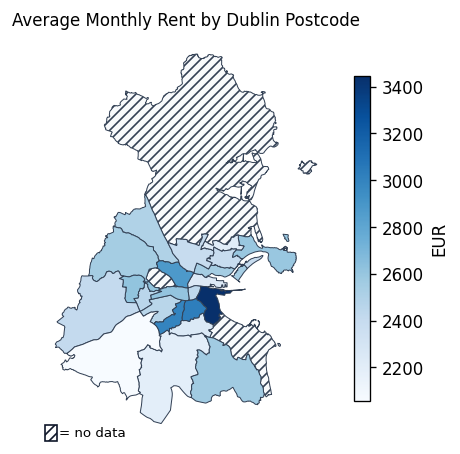

In [424]:
rent_stats = (analytics_base_table.dropna(subset=["postal_district"]).groupby("postal_district", as_index=False)["monthly_rent_eur"].mean().rename(columns={"monthly_rent_eur": "avg_monthly_rent_eur"}))

def make_table(df, columns=None, sort_by=None, ascending=False, top_n=None, title=None, round_decimals=2):
    table_df = df.copy()
    if columns is not None:
        table_df = table_df.loc[:, columns]
    if sort_by is not None:
        table_df = table_df.sort_values(sort_by, ascending=ascending)
    if top_n is not None:
        table_df = table_df.head(top_n)
    if round_decimals is not None:
        num_cols = table_df.select_dtypes(include="number").columns
        table_df.loc[:, num_cols] = table_df.loc[:, num_cols].round(round_decimals)
    if title:
        print(title)
    return table_df.reset_index(drop=True)

top_three_rents = make_table(
    rent_stats,
    columns=["postal_district", "avg_monthly_rent_eur"],
    sort_by="avg_monthly_rent_eur",
    ascending=False,
    top_n=3,
    title="Top 3 postal districts by average monthly rent (EUR)",
)
display(top_three_rents)

postcode_gdf = load_dublin_postcode_shapes()

plot_postcode_map(rent_stats,value_col="avg_monthly_rent_eur", title="Average Monthly Rent by Dublin Postcode", cmap="Blues", legend_label="EUR", postcode_gdf=postcode_gdf, )

As can be seen, there is a clear concentration of higher rents in the central and south-central postal districts of Dublin, with rents generally decreasing as you move towards the outer districts. This indicates that more urban areas of Dublin have higher rents, with more suburban/rural areas offering lower rent (as expected). The map also highlights some postal districts where no data is available, which are indicated by a hatched pattern.

The second map visualizes the total number of listings available by Dublin postal district.

Top 3 postal districts by total listings


,postal_district,total_listings
0,D1,424
1,D2,347
2,D22,61


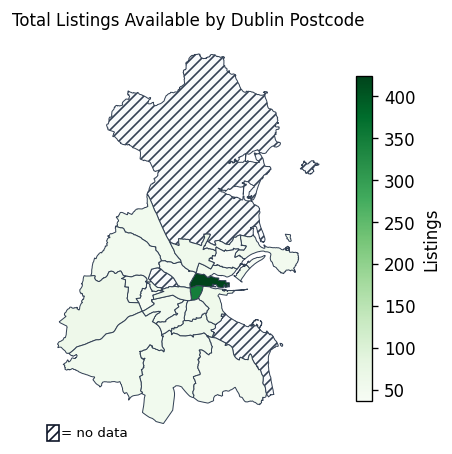

In [425]:
total_stats = (analytics_base_table.dropna(subset=["postal_district"]).groupby("postal_district", as_index=False).size().rename(columns={"size": "total_listings"}))

top_three_listings = make_table(
    total_stats,
    columns=["postal_district", "total_listings"],
    sort_by="total_listings",
    ascending=False,
    top_n=3,
    title="Top 3 postal districts by total listings",
    round_decimals=None,
)
display(top_three_listings)

plot_postcode_map(total_stats, value_col="total_listings", title="Total Listings Available by Dublin Postcode", cmap="Greens", legend_label="Listings", postcode_gdf=postcode_gdf,)

A slightly different trend can be observed here, with the highest number of listings appearing in the central and central-north districts, with D1 and D2 having by far the highest amount of listings, with the rest being significantly lower. This may indicate that while rents are higher in the central and south-central districts, there is a larger supply of rental properties in the central and central-north districts.

### Month Analysis

The next analysis involves examining the distribution of listings over time, specifically by month. This can help identify any seasonal trends in the rental market, such as certain months having more listings than others. To visualize this, I will create a bar chart showing the number of listings available for each month, normalized using min-max normalization to allow for easier comparison across months. The x-axis will represent the listing month, while the y-axis will represent the normalized number of listings (ranging from 0 to 1). This analysis can provide insights into when the rental market is most active and may help renters and landlords make informed decisions about when to list or search for properties.

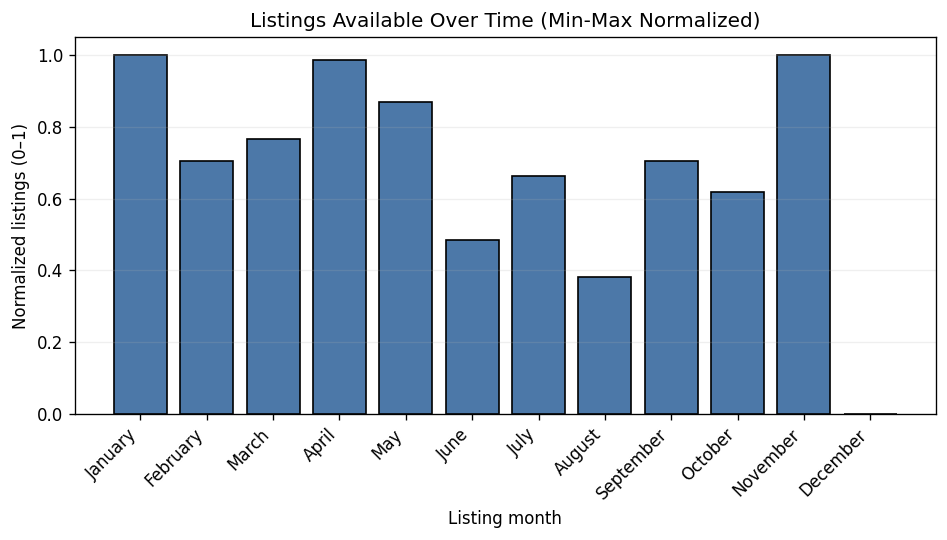

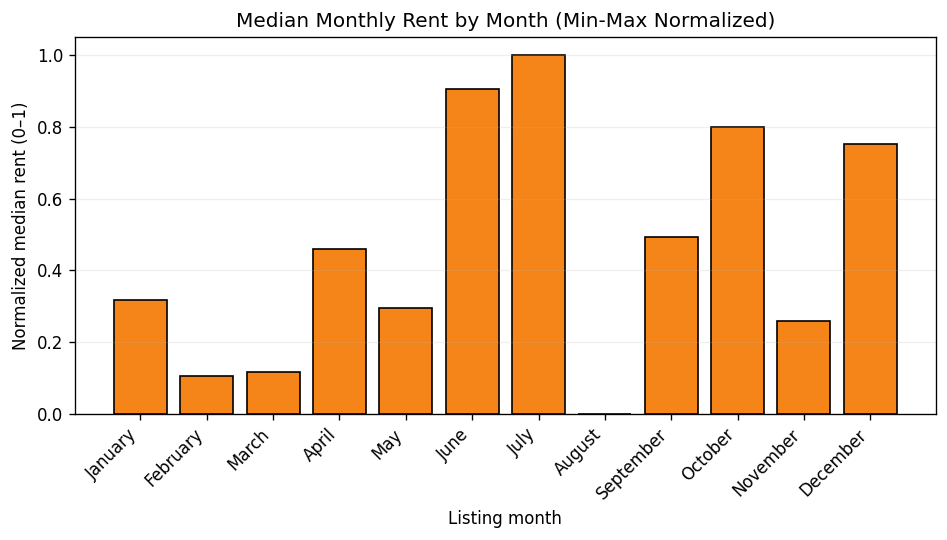

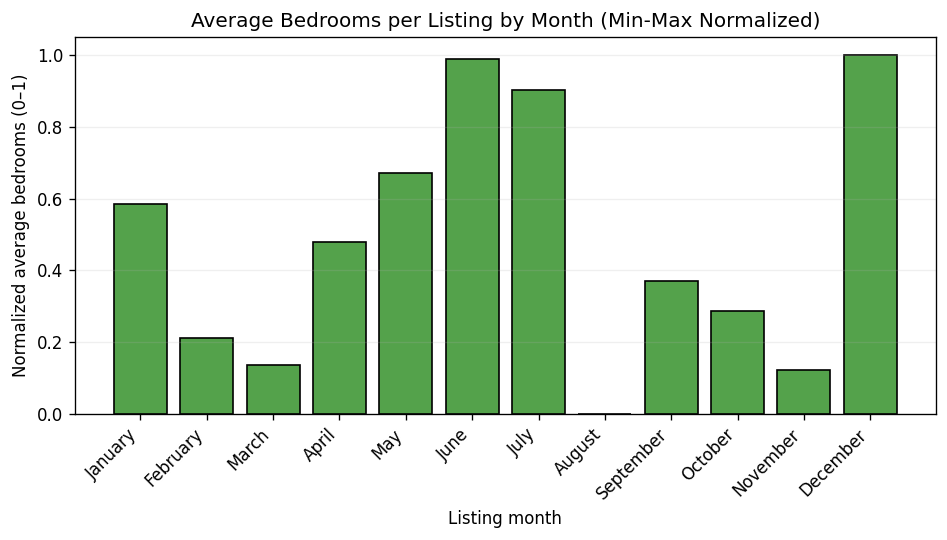

In [426]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

tmp = analytics_base_table.dropna(subset=["listing_month"]).copy()
tmp["listing_month"] = pd.Categorical(tmp["listing_month"], categories=month_order, ordered=True)
tmp["monthly_rent_eur"] = pd.to_numeric(tmp["monthly_rent_eur"], errors="coerce")
tmp["bedrooms_count"] = pd.to_numeric(tmp["bedrooms_count"], errors="coerce")

listing_counts = tmp.groupby("listing_month", observed=False).size().reindex(month_order, fill_value=0)
denom = listing_counts.max() - listing_counts.min()
listing_counts_norm = (listing_counts - listing_counts.min()) / denom if denom != 0 else listing_counts * 0

median_rent = (
    tmp.dropna(subset=["monthly_rent_eur"])
      .groupby("listing_month", observed=False)["monthly_rent_eur"]
      .median()
      .reindex(month_order)
)

avg_bedrooms = (
    tmp.dropna(subset=["bedrooms_count"])
      .groupby("listing_month", observed=False)["bedrooms_count"]
      .mean()
      .reindex(month_order)
)

def minmax_norm(series):
    s_min = series.min(skipna=True)
    s_max = series.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return series.fillna(0) * 0
    return ((series - s_min) / (s_max - s_min)).fillna(0)

median_rent_norm = minmax_norm(median_rent)
avg_bedrooms_norm = minmax_norm(avg_bedrooms)

plt.figure(figsize=(8, 4.6), dpi=120)
plt.bar(month_order, listing_counts_norm.values, color="#4C78A8", edgecolor="black", alpha=1.0)
plt.title("Listings Available Over Time (Min-Max Normalized)")
plt.xlabel("Listing month")
plt.ylabel("Normalized listings (0–1)")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.6), dpi=120)
plt.bar(month_order, median_rent_norm.values, color="#F58518", edgecolor="black", alpha=1.0)
plt.title("Median Monthly Rent by Month (Min-Max Normalized)")
plt.xlabel("Listing month")
plt.ylabel("Normalized median rent (0–1)")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.6), dpi=120)
plt.bar(month_order, avg_bedrooms_norm.values, color="#54A24B", edgecolor="black", alpha=1.0)
plt.title("Average Bedrooms per Listing by Month (Min-Max Normalized)")
plt.xlabel("Listing month")
plt.ylabel("Normalized average bedrooms (0–1)")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

As can be seen by the chart, December has the lowest number of listings, with a significantly increase in listings in November and January through May, with another lull in the summer months of June, July, and August. This may indicate that renters are less likely to move out during the Holiday season and summer months, and 


=== 4.1 Simple Regression (Rent using Bedrooms) ===
Rows used: 1900
Intercept: 658.2953420120066
Coefficient for bedrooms_count: 897.5258229302998


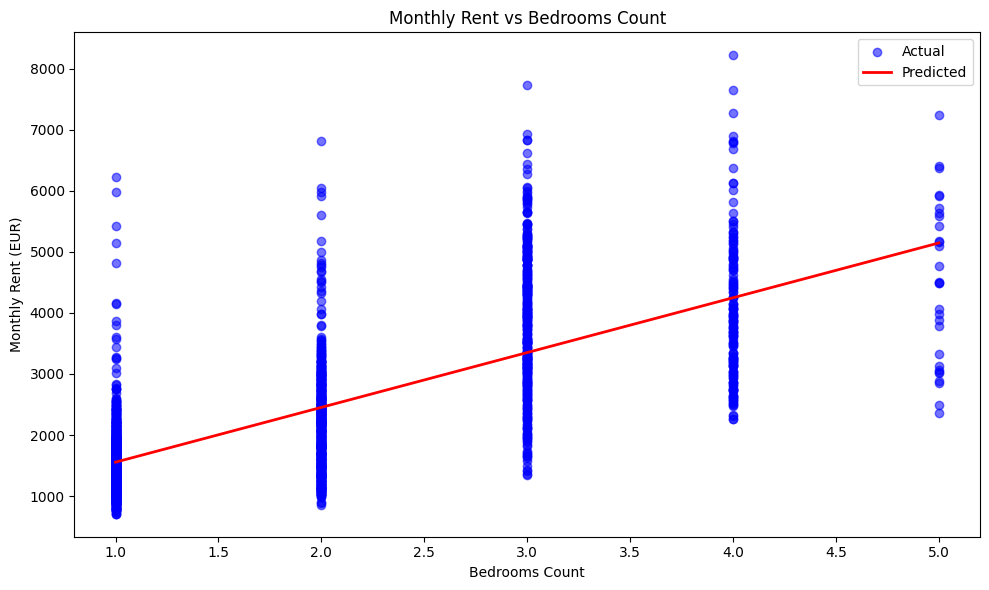

R Squared Value: 0.49561464908360375
Root Mean Squared Error: 925.6010058655788
Mean Absolute Error: 683.1883690870153

Outlier filter on monthly_rent_eur (IQR):
Lower Bound: -946.25
Upper Bound: 5543.75
Rows after outlier removal: 1845

=== 4.2 Simple Regression (Outliers Removed) ===
Rows used: 1845
Intercept: 751.6425265097096
Coefficient for bedrooms_count: 811.6198623255315


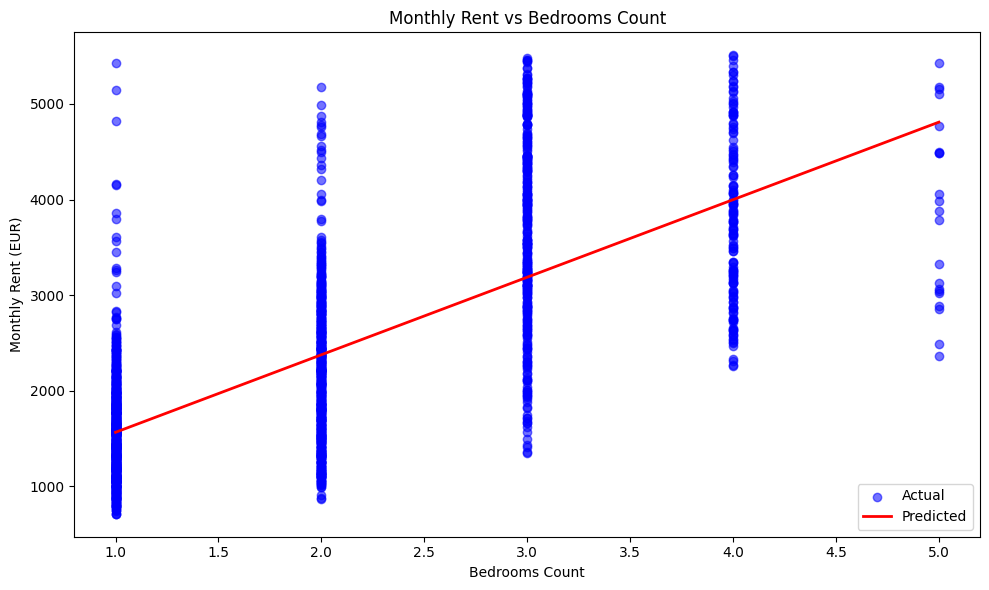

R Squared Value: 0.5025750557146181
Root Mean Squared Error: 803.8871953901164
Mean Absolute Error: 617.6892719025441

=== 4.3 Multiple Regression (Numeric Features) ===
Rows used: 1808
Intercept: 1131.6245237426078
Top coefficients by absolute magnitude:


,coefficient
bedrooms_count,798.513798
lease_months,-35.738707
bathrooms_count,2.784408


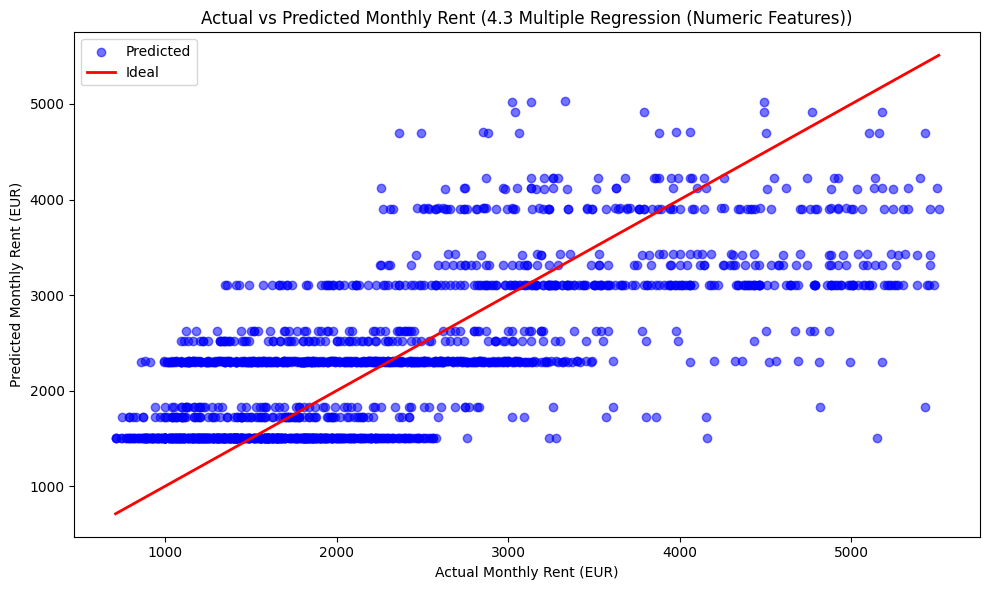

R Squared Value: 0.51265178777927
Root Mean Squared Error: 794.5897836083437
Mean Absolute Error: 614.7610282690453

=== 4.4 Multiple Regression (Numeric + Categorical Dummies) ===
Rows used: 1808
Intercept: 1479.0026390128887
Top coefficients by absolute magnitude:


,coefficient
property_type_House,1075.182382
bedrooms_count,538.688724
postal_district_D4,422.096539
postal_district_D2,391.285472
postal_district_D22,-303.208564
postal_district_D11,-290.551959
postal_district_D24,-251.087704
postal_district_D15,-244.536673
postal_district_D13,-231.545570
postal_district_D5,-225.345827


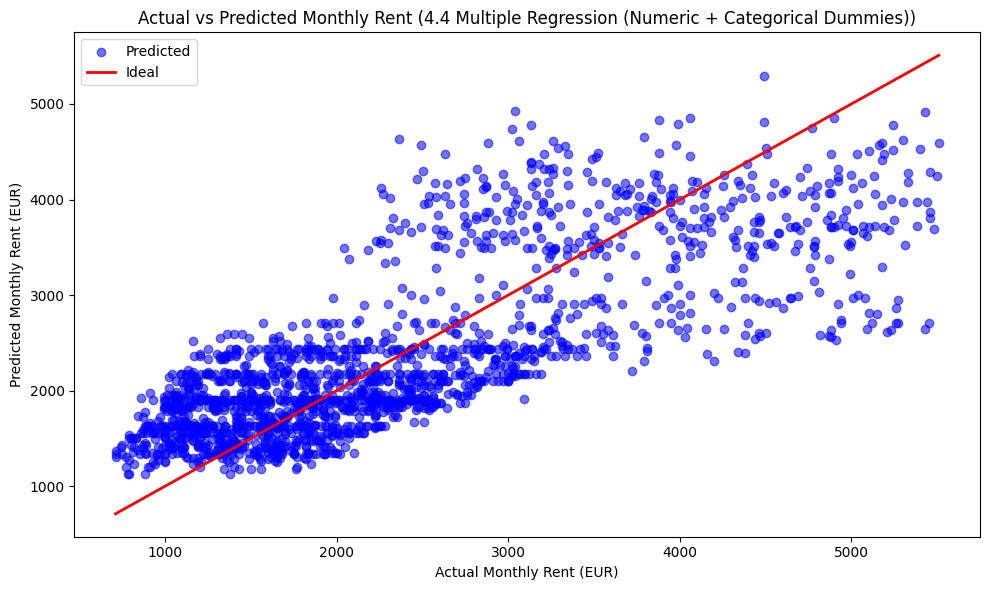

R Squared Value: 0.6058003799388418
Root Mean Squared Error: 714.6302387072673
Mean Absolute Error: 561.6677229963118


In [427]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def run_linear_model(model_name, X, y, plot_mode):
    if len(y) < 10:
        print(f"Skipped {model_name}: not enough rows after cleaning.")
        return None

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    model_rmse = rmse(y, y_pred)
    model_r2 = r2_score(y, y_pred)
    model_mae = mean_absolute_error(y, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Rows used: {len(y)}")
    print("Intercept:", model.intercept_)

    if X.shape[1] == 1:
        print(f"Coefficient for {X.columns[0]}:", model.coef_[0])
    else:
        coef_series = pd.Series(model.coef_, index=X.columns, name="coefficient")
        print("Top coefficients by absolute magnitude:")
        display(coef_series.reindex(coef_series.abs().sort_values(ascending=False).index).head(12).to_frame())

    if plot_mode == "feature_vs_target" and X.shape[1] == 1:
        x_col = X.columns[0]
        sort_idx = np.argsort(X[x_col].to_numpy())
        plt.figure(figsize=(10, 6))
        plt.scatter(X[x_col], y, color="blue", alpha=0.55, label="Actual")
        plt.plot(X[x_col].to_numpy()[sort_idx], y_pred[sort_idx], color="red", linewidth=2, label="Predicted")
        plt.xlabel(x_col.replace("_", " ").title())
        plt.ylabel("Monthly Rent (EUR)")
        plt.title(f"Monthly Rent vs {x_col.replace('_', ' ').title()}")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        y_min = float(np.min(y))
        y_max = float(np.max(y))
        plt.figure(figsize=(10, 6))
        plt.scatter(y, y_pred, color="blue", alpha=0.55, label="Predicted")
        plt.plot([y_min, y_max], [y_min, y_max], color="red", linewidth=2, label="Ideal")
        plt.xlabel("Actual Monthly Rent (EUR)")
        plt.ylabel("Predicted Monthly Rent (EUR)")
        plt.title(f"Actual vs Predicted Monthly Rent ({model_name})")
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f"R Squared Value: {model_r2}")
    print(f"Root Mean Squared Error: {model_rmse}")
    print(f"Mean Absolute Error: {model_mae}")

    return {
        "model": model,
        "r2": model_r2,
        "rmse": model_rmse,
        "mae": model_mae,
        "rows": len(y),
    }

target_col = "monthly_rent_eur"
simple_feature = "bedrooms_count"
numeric_features = [c for c in ["bedrooms_count", "bathrooms_count", "lease_months"] if c in analytics_base_table.columns]
categorical_features = [c for c in ["property_type", "postal_district", "area"] if c in analytics_base_table.columns]

reg_df = analytics_base_table.copy()
reg_df[target_col] = pd.to_numeric(reg_df[target_col], errors="coerce")

for col in numeric_features:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

# 4.1 Simple linear regression: Monthly Rent ~ Bedrooms
if simple_feature in reg_df.columns:
    model_41_data = reg_df[[simple_feature, target_col]].dropna().copy()
    X_41 = model_41_data[[simple_feature]]
    y_41 = model_41_data[target_col]
    model_41_result = run_linear_model(
        model_name="4.1 Simple Regression (Rent using Bedrooms)",
        X=X_41,
        y=y_41,
        plot_mode="feature_vs_target",
    )
else:
    print("Skipped 4.1: bedrooms_count column not found.")

# Remove outliers on rent using IQR (used for 4.2, 4.3, 4.4)
clean_df = reg_df.dropna(subset=[target_col]).copy()
if len(clean_df) >= 10:
    q1 = clean_df[target_col].quantile(0.25)
    q3 = clean_df[target_col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    clean_df = clean_df[(clean_df[target_col] >= lower_bound) & (clean_df[target_col] <= upper_bound)].copy()
else:
    lower_bound, upper_bound = np.nan, np.nan

print("\nOutlier filter on monthly_rent_eur (IQR):")
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Rows after outlier removal:", len(clean_df))

# 4.2 Simple linear regression on cleaned data
if simple_feature in clean_df.columns:
    model_42_data = clean_df[[simple_feature, target_col]].dropna().copy()
    X_42 = model_42_data[[simple_feature]]
    y_42 = model_42_data[target_col]
    model_42_result = run_linear_model(
        model_name="4.2 Simple Regression (Outliers Removed)",
        X=X_42,
        y=y_42,
        plot_mode="feature_vs_target",
    )
else:
    print("Skipped 4.2: bedrooms_count column not found.")

# 4.3 Multiple regression using numeric listing metrics
if len(numeric_features) >= 2:
    model_43_data = clean_df[numeric_features + [target_col]].dropna().copy()
    X_43 = model_43_data[numeric_features]
    y_43 = model_43_data[target_col]
    model_43_result = run_linear_model(
        model_name="4.3 Multiple Regression (Numeric Features)",
        X=X_43,
        y=y_43,
        plot_mode="actual_vs_pred",
    )
else:
    print("Skipped 4.3: need at least two numeric predictors from bedrooms_count, bathrooms_count, lease_months.")

# 4.4 Multiple regression using numeric + categorical features (dummy encoded)
if len(numeric_features) >= 1:
    if len(categorical_features) > 0:
        cat_df = clean_df[categorical_features].copy()
        for col in categorical_features:
            cat_df[col] = (
                cat_df[col]
                .astype("string")
                .str.strip()
                .replace("<NA>", "Unknown")
                .fillna("Unknown")
            )
        cat_dummies = pd.get_dummies(cat_df, drop_first=True, dtype=float)
        X_44_full = pd.concat([clean_df[numeric_features], cat_dummies], axis=1)
    else:
        X_44_full = clean_df[numeric_features].copy()

    model_44_data = pd.concat([X_44_full, clean_df[target_col]], axis=1).dropna().copy()

    if model_44_data.shape[1] >= 3:
        X_44 = model_44_data.drop(columns=[target_col])
        y_44 = model_44_data[target_col]
        model_44_result = run_linear_model(
            model_name="4.4 Multiple Regression (Numeric + Categorical Dummies)",
            X=X_44,
            y=y_44,
            plot_mode="actual_vs_pred",
        )
    else:
        print("Skipped 4.4: not enough predictor columns after encoding.")
else:
    print("Skipped 4.4: no numeric predictors available.")


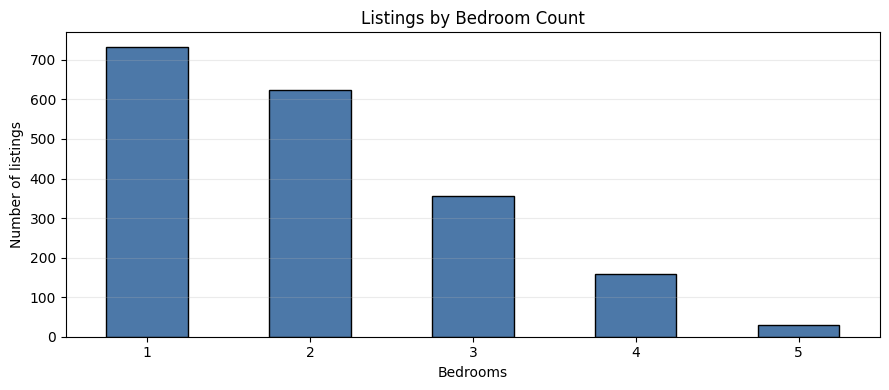

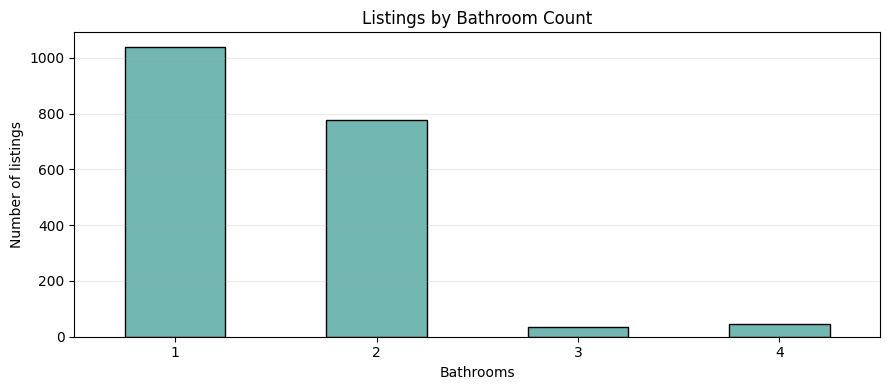

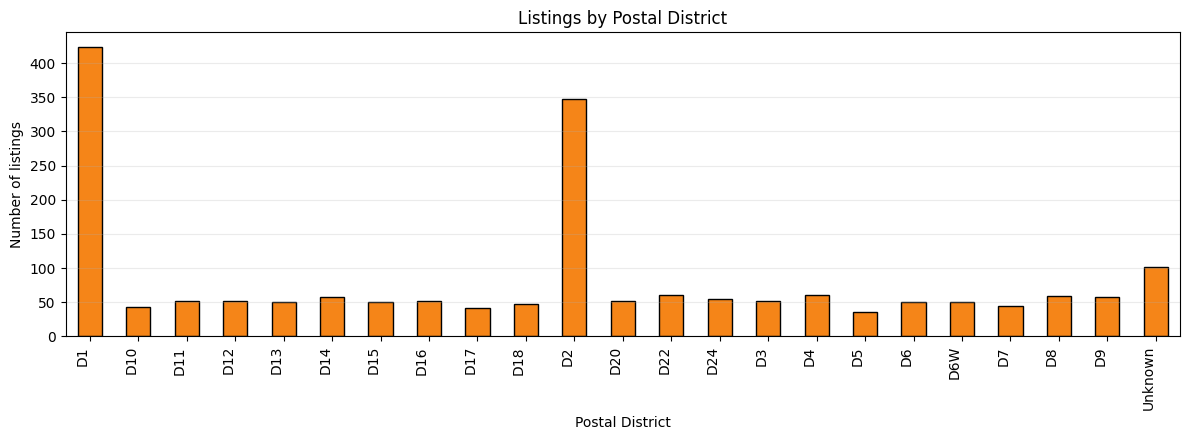

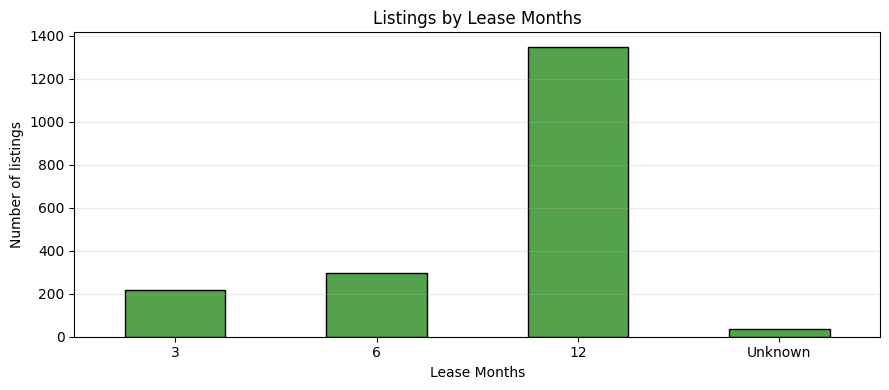

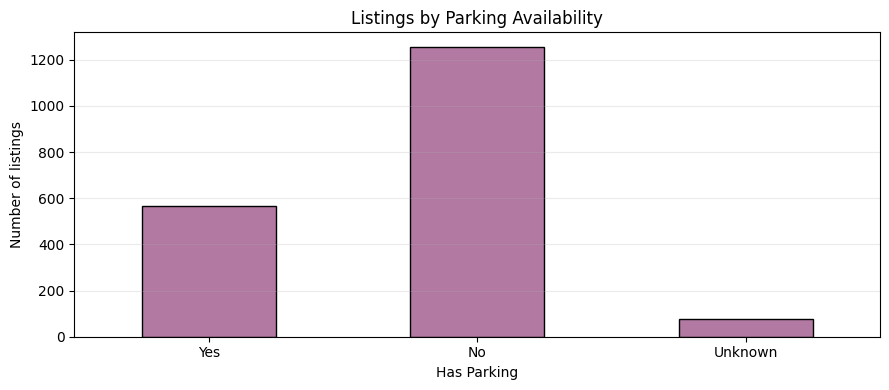

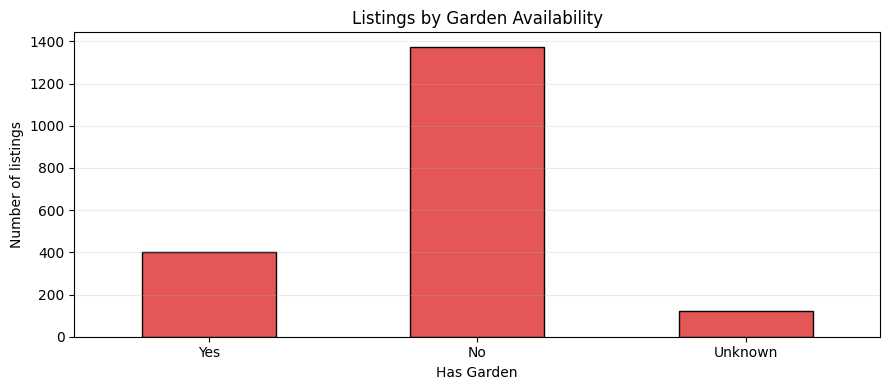

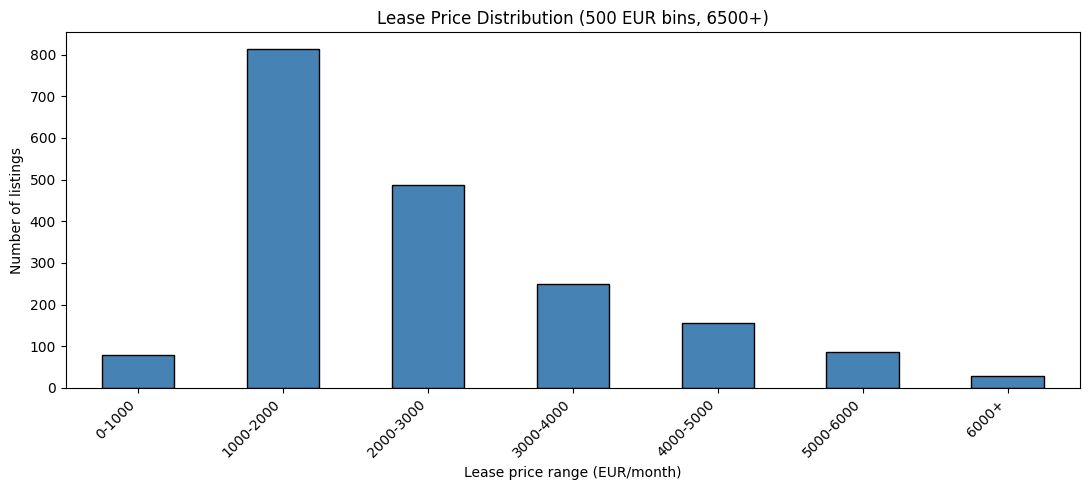

In [428]:
viz_df = analytics_base_table.copy()

def ordered_numeric_counts(series):
    s = pd.to_numeric(series, errors="coerce").round().astype("Int64").astype("string")
    s = s.replace("<NA>", "Unknown").fillna("Unknown")
    counts = s.value_counts()
    known = counts[counts.index != "Unknown"]
    if len(known) > 0:
        known = known.reindex(sorted(known.index, key=lambda x: int(x)))
    if "Unknown" in counts.index:
        known.loc["Unknown"] = counts["Unknown"]
    return known

def yes_no_unknown_counts(series):
    s = series.astype("string").str.strip().str.lower()
    mapped = s.map({"true": "Yes", "false": "No", "1": "Yes", "0": "No", "yes": "Yes", "no": "No"})
    mapped = mapped.fillna("Unknown")
    return mapped.value_counts().reindex(["Yes", "No", "Unknown"], fill_value=0)

def plot_count_bar(counts, title, xlabel, color, rotate=0, figsize=(9, 4)):
    plt.figure(figsize=figsize)
    counts.plot(kind="bar", color=color, edgecolor="black", alpha=1.0)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of listings")
    plt.xticks(rotation=rotate, ha="right" if rotate else "center")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

bedroom_counts = ordered_numeric_counts(viz_df["bedrooms_count"])
bathroom_counts = ordered_numeric_counts(viz_df["bathrooms_count"])
lease_month_counts = ordered_numeric_counts(viz_df["lease_months"])

postal_counts = (
    viz_df["postal_district"]
      .astype("string")
      .replace("<NA>", "Unknown")
      .fillna("Unknown")
      .value_counts()
      .sort_index()
)

parking_counts = yes_no_unknown_counts(viz_df["has_parking"])
garden_counts = yes_no_unknown_counts(viz_df["has_garden"])

plot_count_bar(bedroom_counts, "Listings by Bedroom Count", "Bedrooms", "#4C78A8")
plot_count_bar(bathroom_counts, "Listings by Bathroom Count", "Bathrooms", "#72B7B2")
plot_count_bar(postal_counts, "Listings by Postal District", "Postal District", "#F58518", rotate=90, figsize=(12, 4.5))
plot_count_bar(lease_month_counts, "Listings by Lease Months", "Lease Months", "#54A24B")
plot_count_bar(parking_counts, "Listings by Parking Availability", "Has Parking", "#B279A2")
plot_count_bar(garden_counts, "Listings by Garden Availability", "Has Garden", "#E45756")


import pandas as pd
import matplotlib.pyplot as plt

# Clean price column
tmp = analytics_base_table.copy()
tmp["monthly_rent_eur"] = pd.to_numeric(tmp["monthly_rent_eur"], errors="coerce")
tmp = tmp.dropna(subset=["monthly_rent_eur"])

# 500-EUR bins from 0 to 6500, then 6500+
bin_edges = list(range(0, 6001, 1000)) + [float("inf")]
bin_labels = [f"{start}-{start + 1000}" for start in range(0, 6000, 1000)] + ["6000+"]
tmp["lease_price_bin"] = pd.cut(
    tmp["monthly_rent_eur"],
    bins=bin_edges,
    labels=bin_labels,
    right=False,
    include_lowest=True,
)
bin_counts = tmp["lease_price_bin"].value_counts(sort=False)

# Bar chart
plt.figure(figsize=(11, 5))
bin_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Lease price range (EUR/month)")
plt.ylabel("Number of listings")
plt.title("Lease Price Distribution (500 EUR bins, 6500+)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

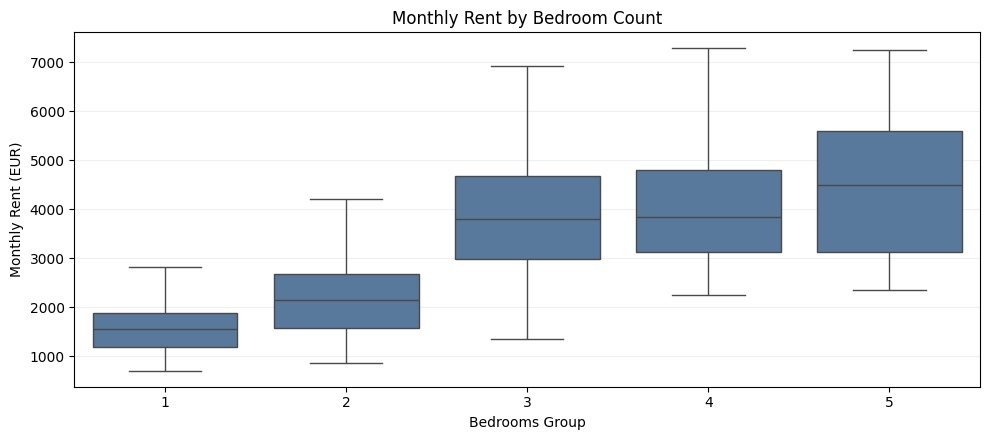

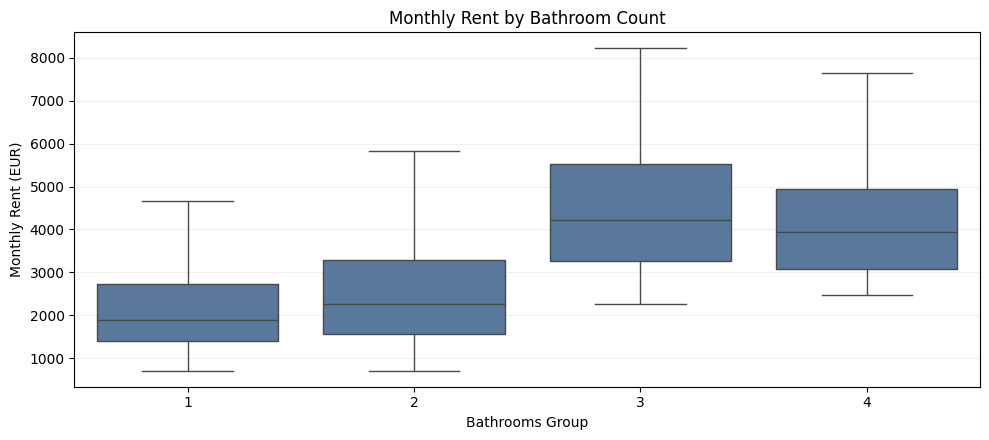

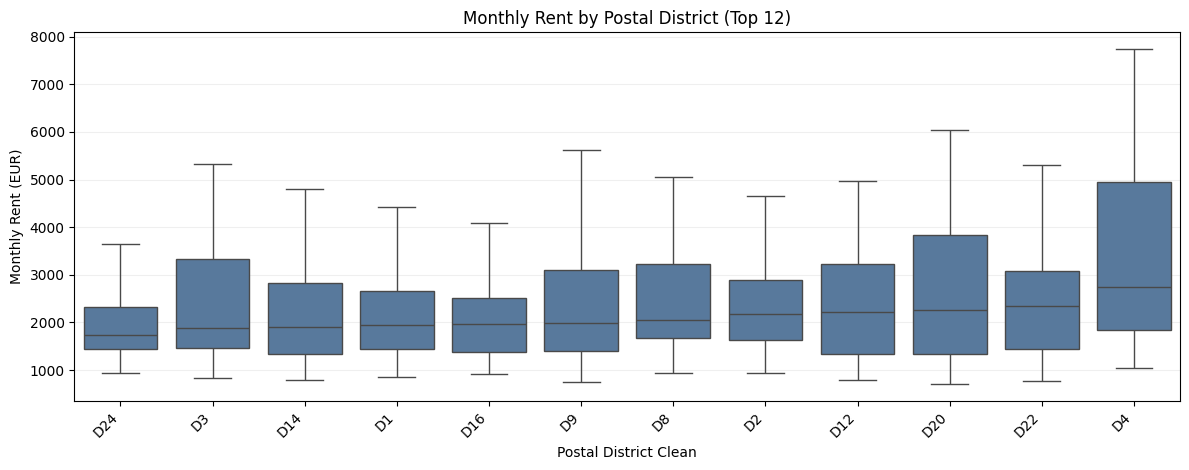

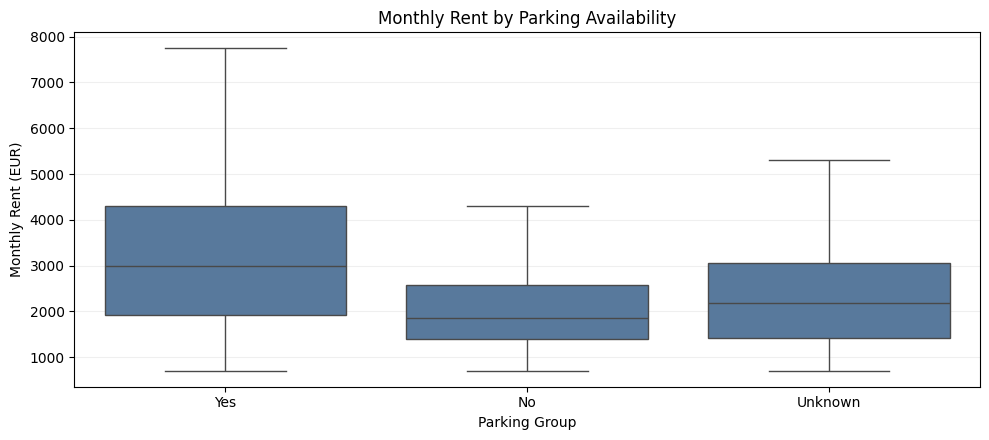

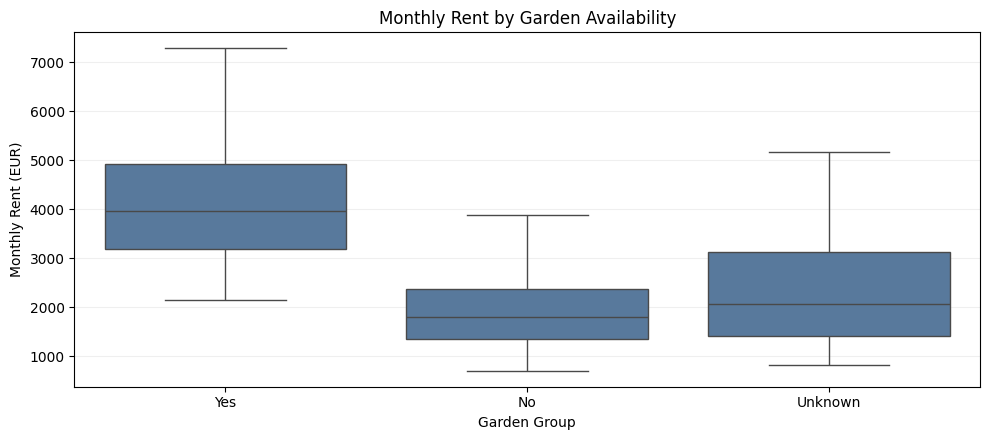

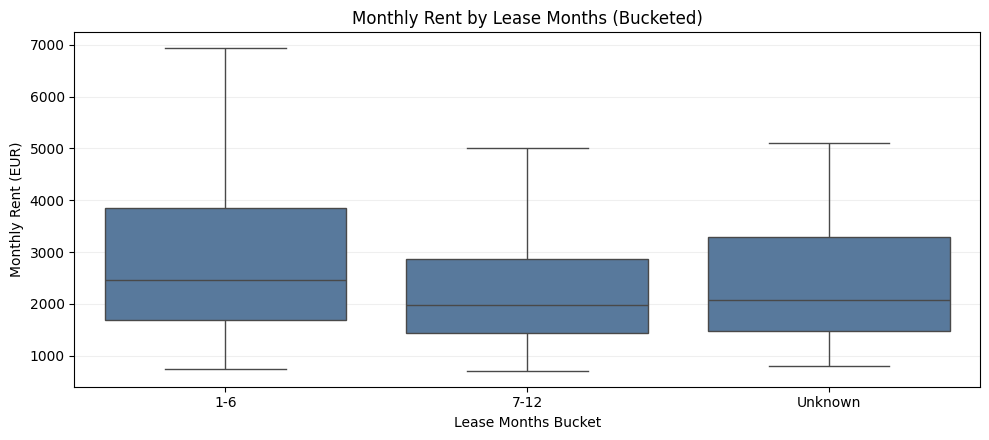

In [429]:
import numpy as np
import seaborn as sns

box_df = analytics_base_table.copy()
box_df["monthly_rent_eur"] = pd.to_numeric(box_df["monthly_rent_eur"], errors="coerce")
box_df = box_df.dropna(subset=["monthly_rent_eur"])
box_df = box_df[box_df["monthly_rent_eur"] > 0].copy()

def map_yes_no_unknown(series):
    s = series.astype("string").str.strip().str.lower()
    return s.map({"true": "Yes", "false": "No", "1": "Yes", "0": "No", "yes": "Yes", "no": "No"}).fillna("Unknown")

def make_ordered_numeric_labels(series):
    n = pd.to_numeric(series, errors="coerce").round().astype("Int64")
    labels = n.astype("string").fillna("Unknown")
    order = [str(int(v)) for v in sorted(n.dropna().unique())]
    if (labels == "Unknown").any():
        order.append("Unknown")
    return labels, order

def filter_min_count(df, cat_col, min_count=20):
    keep = df[cat_col].value_counts()
    keep = keep[keep >= min_count].index
    return df[df[cat_col].isin(keep)].copy()

def draw_rent_boxplot(df, x_col, title, order=None, rotate=0, figsize=(10, 4.5), showfliers=False):
    plt.figure(figsize=figsize)
    sns.boxplot(
        data=df,
        x=x_col,
        y="monthly_rent_eur",
        order=order,
        showfliers=showfliers,
        color="#4C78A8",
        linewidth=1,
    )
    plt.title(title)
    plt.xlabel(x_col.replace("_", " ").title())
    plt.ylabel("Monthly Rent (EUR)")
    plt.xticks(rotation=rotate, ha="right" if rotate else "center")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

# 1) Monthly rent by bedroom count
box_df["bedrooms_group"], bedrooms_order = make_ordered_numeric_labels(box_df["bedrooms_count"])
bedroom_df = filter_min_count(box_df, "bedrooms_group", min_count=20)
bedrooms_order = [c for c in bedrooms_order if c in bedroom_df["bedrooms_group"].unique()]
draw_rent_boxplot(
    bedroom_df,
    x_col="bedrooms_group",
    title="Monthly Rent by Bedroom Count",
    order=bedrooms_order,
)

# 2) Monthly rent by bathroom count
box_df["bathrooms_group"], bathrooms_order = make_ordered_numeric_labels(box_df["bathrooms_count"])
bathroom_df = filter_min_count(box_df, "bathrooms_group", min_count=20)
bathrooms_order = [c for c in bathrooms_order if c in bathroom_df["bathrooms_group"].unique()]
draw_rent_boxplot(
    bathroom_df,
    x_col="bathrooms_group",
    title="Monthly Rent by Bathroom Count",
    order=bathrooms_order,
)

# 3) Monthly rent by postal district (top districts only)
box_df["postal_district_clean"] = box_df["postal_district"].astype("string").replace("<NA>", np.nan)
postal_counts = box_df["postal_district_clean"].dropna().value_counts()
postal_keep = postal_counts[postal_counts >= 20].head(12).index
postal_df = box_df[box_df["postal_district_clean"].isin(postal_keep)].copy()
postal_order = postal_df.groupby("postal_district_clean")["monthly_rent_eur"].median().sort_values().index.tolist()
draw_rent_boxplot(
    postal_df,
    x_col="postal_district_clean",
    title="Monthly Rent by Postal District (Top 12)",
    order=postal_order,
    rotate=45,
    figsize=(12, 4.8),
)

# 4) Monthly rent by parking availability
box_df["parking_group"] = map_yes_no_unknown(box_df["has_parking"])
parking_df = filter_min_count(box_df, "parking_group", min_count=20)
parking_order = [c for c in ["Yes", "No", "Unknown"] if c in parking_df["parking_group"].unique()]
draw_rent_boxplot(
    parking_df,
    x_col="parking_group",
    title="Monthly Rent by Parking Availability",
    order=parking_order,
)

# 5) Monthly rent by garden availability
box_df["garden_group"] = map_yes_no_unknown(box_df["has_garden"])
garden_df = filter_min_count(box_df, "garden_group", min_count=20)
garden_order = [c for c in ["Yes", "No", "Unknown"] if c in garden_df["garden_group"].unique()]
draw_rent_boxplot(
    garden_df,
    x_col="garden_group",
    title="Monthly Rent by Garden Availability",
    order=garden_order,
)

# 6) Monthly rent by lease months (bucketed)
lease_num = pd.to_numeric(box_df["lease_months"], errors="coerce")
box_df["lease_months_bucket"] = pd.cut(
    lease_num,
    bins=[0, 6, 12, 24, np.inf],
    labels=["1-6", "7-12", "13-24", "25+"],
    include_lowest=True,
).astype("string").fillna("Unknown")
lease_df = filter_min_count(box_df, "lease_months_bucket", min_count=20)
lease_order = [c for c in ["1-6", "7-12", "13-24", "25+", "Unknown"] if c in lease_df["lease_months_bucket"].unique()]
draw_rent_boxplot(
    lease_df,
    x_col="lease_months_bucket",
    title="Monthly Rent by Lease Months (Bucketed)",
    order=lease_order,
)


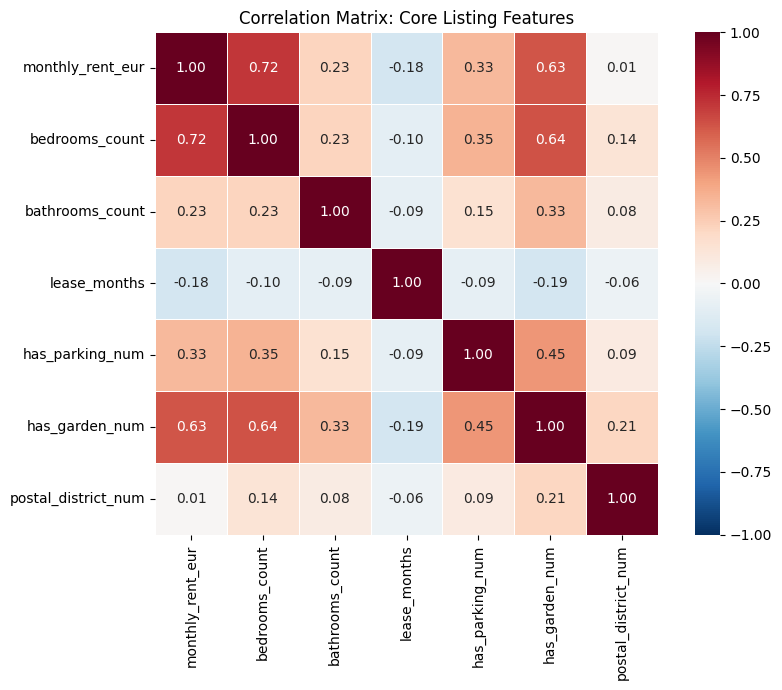

In [430]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def to_yes_no_numeric(series):
    s = series.astype("string").str.strip().str.lower()
    return s.map({
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0,
        "yes": 1,
        "no": 0,
        "y": 1,
        "n": 0,
    })

def maybe_numeric(series):
    return pd.to_numeric(series, errors="coerce")

def plot_correlation_matrix(df, title, method="spearman", min_non_null=25, figsize=(9, 7)):
    usable = [c for c in df.columns if df[c].notna().sum() >= min_non_null]
    if len(usable) < 2:
        print(f"Skipped '{title}' (not enough usable columns).")
        return

    corr = df[usable].corr(method=method)
    if corr.shape[0] < 2:
        print(f"Skipped '{title}' (not enough comparable columns).")
        return

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        square=True,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

core_corr_df = pd.DataFrame(index=analytics_base_table.index)

for col in ["monthly_rent_eur", "bedrooms_count", "bathrooms_count", "lease_months"]:
    if col in analytics_base_table.columns:
        core_corr_df[col] = maybe_numeric(analytics_base_table[col])

for col in ["has_parking", "has_garden"]:
    if col in analytics_base_table.columns:
        core_corr_df[f"{col}_num"] = to_yes_no_numeric(analytics_base_table[col])

if "postal_district" in analytics_base_table.columns:
    core_corr_df["postal_district_num"] = (
        analytics_base_table["postal_district"]
        .astype("string")
        .str.extract(r"(\d+)", expand=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

plot_correlation_matrix(
    core_corr_df,
    title="Correlation Matrix: Core Listing Features",
    method="spearman",
)


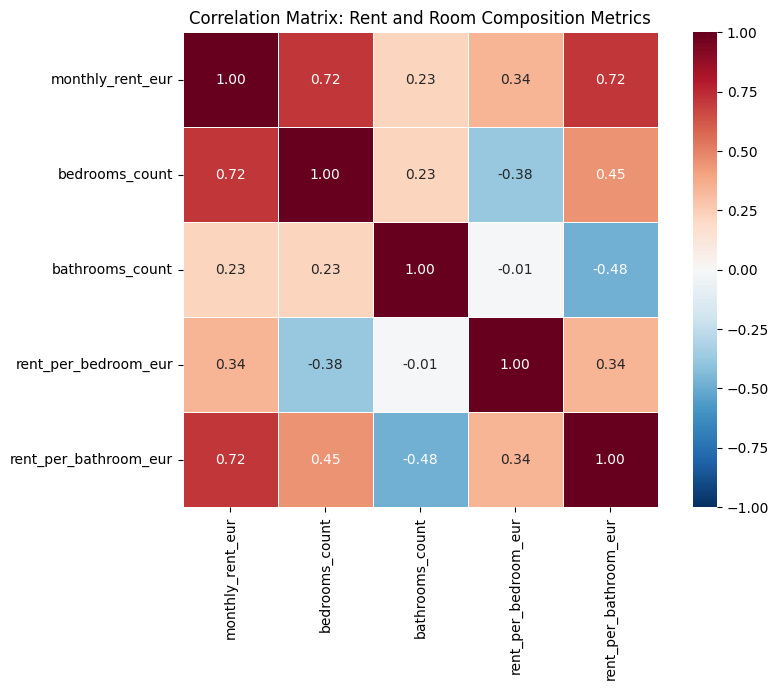

In [431]:
derived_corr_df = pd.DataFrame(index=analytics_base_table.index)

if "monthly_rent_eur" in analytics_base_table.columns:
    rent = pd.to_numeric(analytics_base_table["monthly_rent_eur"], errors="coerce")
    derived_corr_df["monthly_rent_eur"] = rent
else:
    rent = pd.Series(np.nan, index=analytics_base_table.index)

if "bedrooms_count" in analytics_base_table.columns:
    bedrooms = pd.to_numeric(analytics_base_table["bedrooms_count"], errors="coerce")
    derived_corr_df["bedrooms_count"] = bedrooms
else:
    bedrooms = pd.Series(np.nan, index=analytics_base_table.index)

if "bathrooms_count" in analytics_base_table.columns:
    bathrooms = pd.to_numeric(analytics_base_table["bathrooms_count"], errors="coerce")
    derived_corr_df["bathrooms_count"] = bathrooms
else:
    bathrooms = pd.Series(np.nan, index=analytics_base_table.index)

if rent.notna().any() and bedrooms.notna().any():
    derived_corr_df["rent_per_bedroom_eur"] = np.where(bedrooms > 0, rent / bedrooms, np.nan)

if rent.notna().any() and bathrooms.notna().any():
    derived_corr_df["rent_per_bathroom_eur"] = np.where(bathrooms > 0, rent / bathrooms, np.nan)

plot_correlation_matrix(
    derived_corr_df,
    title="Correlation Matrix: Rent and Room Composition Metrics",
    method="spearman",
)
